In [2]:
# Import Packages 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
!pip install linearmodels
try:
    from linearmodels.iv import IV2SLS
    HAVE_LINEARMODELS = True
except ImportError:
    HAVE_LINEARMODELS = False
    print("Note: linearmodels not installed. Python IV/2SLS section will not run until installed.")


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
# Load Datasets 
raw_data = pd.read_csv('final_hcris.csv')
data_2009 = pd.read_csv('data/output/data-2009.csv')
data_2010 = pd.read_csv('data/output/data-2010.csv')
data_2011 = pd.read_csv('data/output/data-2011.csv')
data_2012 = pd.read_csv('data/output/data-2012.csv')
data_2013 = pd.read_csv('data/output/data-2013.csv')
data_2014 = pd.read_csv('data/output/data-2014.csv')
data_2015 = pd.read_csv('data/output/data-2015.csv')
data_2016 = pd.read_csv('data/output/data-2016.csv')
data_2017 = pd.read_csv('data/output/data-2017.csv')
data_2018 = pd.read_csv('data/output/data-2018.csv')
data_2019 = pd.read_csv('data/output/data-2019.csv')
data = pd.concat([data_2009, data_2010, data_2011, data_2012, data_2013, data_2014, data_2015, data_2016, data_2017, data_2018, data_2019], ignore_index=True)

In [4]:
data.columns

Index(['provider_number', 'fy_start', 'fy_end', 'date_processed',
       'date_created', 'data_source', 'beds', 'tot_charges', 'net_pat_rev',
       'tot_discounts', 'tot_operating_exp', 'ip_charges', 'icu_charges',
       'ancillary_charges', 'tot_discharges', 'mcare_discharges',
       'mcaid_discharges', 'tot_mcare_payment', 'secondary_mcare_payment',
       'street', 'city', 'state', 'zip', 'county', 'name', 'uncomp_care',
       'cost_to_charge', 'new_cap_ass', 'cash', 'fixed_assets', 'depr_land',
       'depr_bldg', 'depr_lease', 'depr_fixed_equip', 'depr_auto',
       'depr_major_equip', 'depr_minor_equip', 'current_assets',
       'current_liabilities', 'pps_ip_charges', 'pps_op_charges',
       'pps_mcare_cost', 'pps_pgm_cost', 'hvbp_payment', 'hrrp_payment',
       'tot_uncomp_care_charges', 'tot_uncomp_care_partial_pmts', 'bad_debt',
       'depr_HIT', 'year', 'source'],
      dtype='object')

In [5]:
data["name"].unique()

array(['SOUTHEAST ALABAMA MEDICAL CENTER',
       'MARSHALL MEDICAL CENTER - SOUTH',
       'ELIZA COFFEE MEMORIAL HOSPITAL', ...,
       'PAM REHAB HOSPITAL CORPUS CHRISTI', 'SUGAR LAND REHAB HOSPITAL',
       'PAM REHAB HOSP OF ROUND ROCK'], shape=(9723,), dtype=object)

## Question 1

In [6]:
question_1 = (
    raw_data
    .groupby(["fyear", "provider_number"])
    .size()
    .reset_index(name="num_reports")
)
multiple_reports = question_1[question_1["num_reports"] > 1]
multiple_reports.head()

,fyear,provider_number,num_reports
106,2008,30061,2
118,2008,30093,2
183,2008,40151,2
260,2008,50158,2
272,2008,50230,2


In [7]:
hospitals_per_year = (
    multiple_reports
    .groupby("fyear")["provider_number"]
    .nunique()
    .reindex(range(2009, 2020), fill_value=0)
    .reset_index(name="num_hospitals")
)
hospitals_per_year

,fyear,num_hospitals
0,2009,87
1,2010,91
2,2011,66
3,2012,90
4,2013,91
5,2014,102
6,2015,96
7,2016,95
8,2017,91
9,2018,116


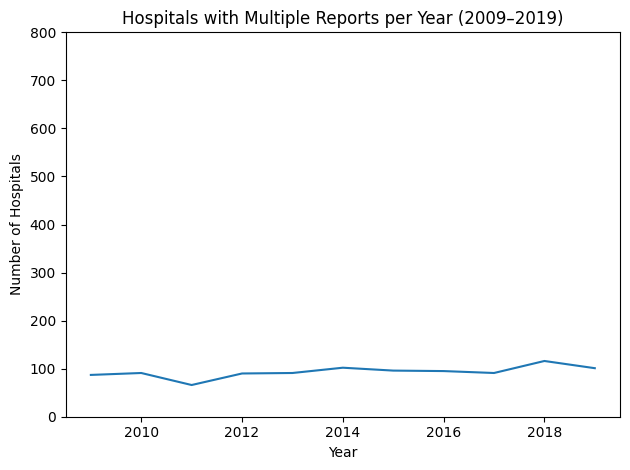

In [8]:
fig, ax = plt.subplots()

ax.plot(
    hospitals_per_year["fyear"],
    hospitals_per_year["num_hospitals"]
)

ax.set(
    xlabel="Year",
    ylabel="Number of Hospitals",
    title="Hospitals with Multiple Reports per Year (2009–2019)"
)
ax.set_ylim(0, 800)

plt.tight_layout()
plt.show()

## Question 2

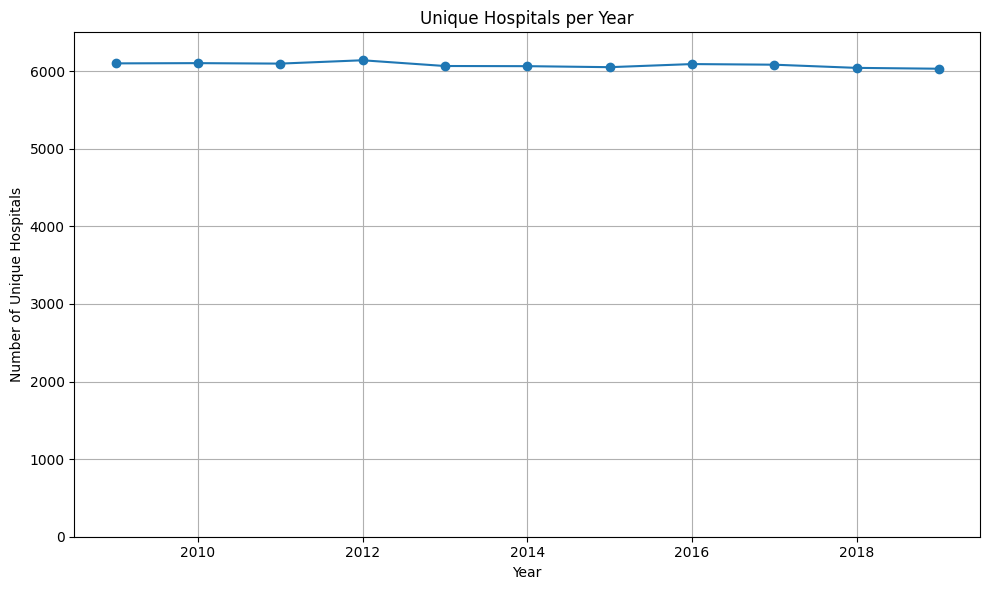

In [9]:
question_2 = data.groupby("year")["provider_number"].nunique()
plt.figure(figsize=(10, 6))
plt.plot(question_2.index, question_2.values, marker="o")

plt.xlabel("Year")
plt.ylabel("Number of Unique Hospitals")
plt.title("Unique Hospitals per Year")

plt.grid(True)
plt.ylim(0, 6500)
plt.tight_layout()
plt.show()

In [12]:
unique_ids = data["provider_number"].unique()
len(unique_ids)

6893

There are 6,893 unique hospital ids included in the dataset. 

## Question 3

/tmp/ipykernel_1613911/2269311395.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(winsorize_group3)


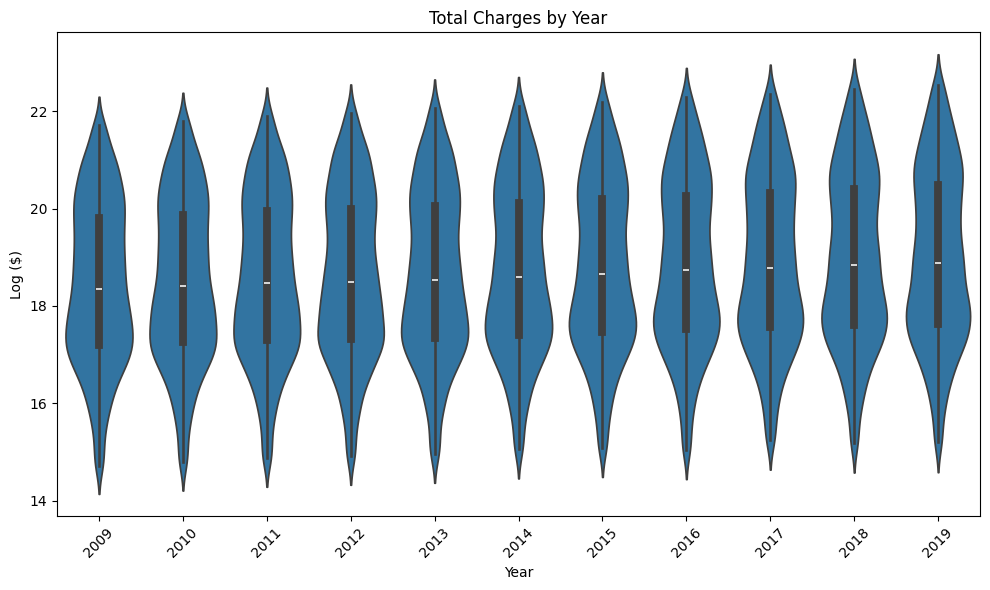

In [13]:
def winsorize_group3(g):
    p99 = g["tot_charges"].quantile(0.99)
    p01 = g["tot_charges"].quantile(0.01)
    g["tot_charges"] = g["tot_charges"].clip(lower=p01, upper=p99)
    return g

question_3 = data.copy() 

winsorized_data3 = (
    question_3.groupby("year", group_keys=False)
    .apply(winsorize_group3)
)

plt.figure(figsize=(10, 6))

winsorized_data3["log_tot_charges"] = np.log(winsorized_data3["tot_charges"])

sns.violinplot(
    data=winsorized_data3,
    x="year",
    y="log_tot_charges",
)

plt.xlabel("Year")
plt.ylabel("Log ($)")
plt.title("Total Charges by Year")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 4

In [58]:
# Price calculation
data["discount_factor"] = 1 - (data["tot_discounts"] / data["tot_charges"])
data["price_num"] = (data["ip_charges"] + data["icu_charges"] + data["ancillary_charges"]) * data["discount_factor"] - data["tot_mcare_payment"]
data["price_denom"] = data["tot_discharges"] - data["mcare_discharges"]
data["price"] = data["price_num"] / data["price_denom"]

In [61]:
data_price = data[(data["price_denom"] > 100) & (data["price_num"] >= 0) & (data["beds"] > 30) & (data["price"] < 100000)].copy()

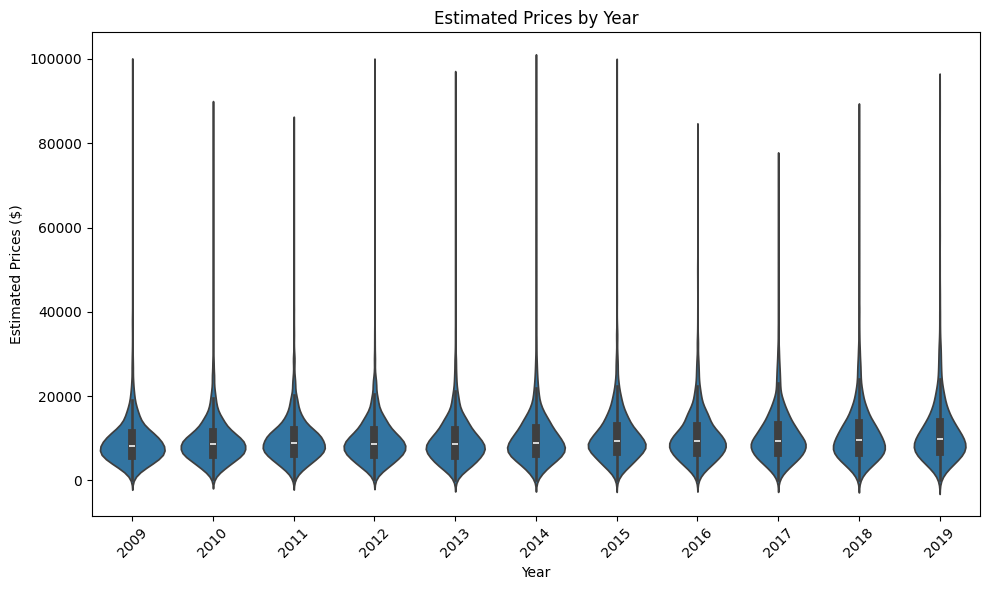

In [62]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=data_price,
    x="year",
    y="price"
)

plt.xlabel("Year")
plt.ylabel("Estimated Prices ($)")
plt.title("Estimated Prices by Year")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Question 5

In [63]:
share_year = (
    data
    .assign(
        penalized=np.where(
            (data["hrrp_payment"].fillna(0) != 0) | 
            (data["hvbp_payment"].fillna(0) != 0),
            1,
            0
        )
    )
    .groupby("year", as_index=False)
    .agg(share_penalized=("penalized", "mean"))
)

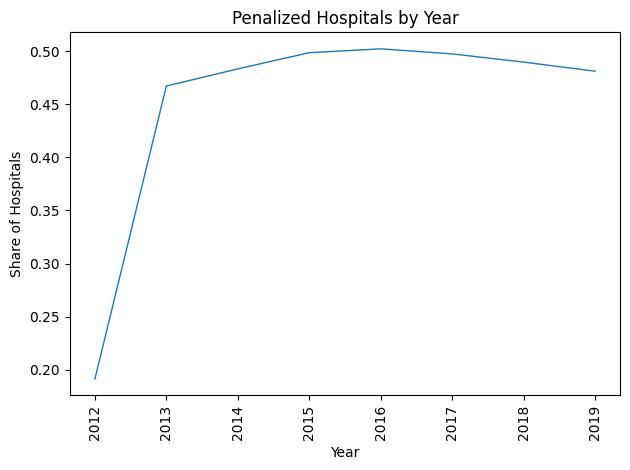

In [64]:
question_5 = share_year[share_year["year"] > 2011]
fig, ax = plt.subplots()
ax.plot(question_5["year"].astype(str), question_5["share_penalized"], linewidth=1)
ax.set_xlabel("Year")
ax.set_ylabel("Share of Hospitals")
ax.set_title("Penalized Hospitals by Year")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## Question 6

In [69]:
# Prices 
hcris_price = (
    data_price.loc[data_price["year"].isin([2011, 2014]), ["provider_number", "price", "year"]]
    .pivot(index="provider_number", columns="year", values="price")
    .rename(columns=lambda y: f"price_{int(y)}")
    .reset_index()
)

# Penalties 2012
hcris_hrrp = (
    data.loc[data["year"].eq(2012), ["provider_number", "hrrp_payment", "hvbp_payment"]]
    .assign(
        hrrp_penalty=lambda df: np.where(
            df["hrrp_payment"].notna() & (df["hrrp_payment"] != 0),
            np.abs(df["hrrp_payment"]),  
            0.0
        ),
        hvbp_penalty=lambda df: np.where(
            df["hvbp_payment"].notna() & (df["hvbp_payment"] != 0),
            np.abs(df["hvbp_payment"]),  
            0.0
        )
    )
    .assign(
        net_penalty=lambda df: df["hrrp_penalty"] + df["hvbp_penalty"]
    )
    .loc[:, ["provider_number", "hrrp_penalty", "hvbp_penalty", "net_penalty"]]
)

# Medicare discharges (pre-2012 average)
hcris_mcare = (
    data.loc[data["year"] < 2012, ["provider_number", "mcare_discharges", "beds", "mcaid_discharges"]]
    .groupby("provider_number", as_index=False)
    .agg(
        avg_mcare=("mcare_discharges", lambda x: np.nanmean(x)),
        avg_beds=("beds", lambda x: np.nanmean(x)),
        avg_medicaid=("mcaid_discharges", lambda x: np.nanmean(x))
    )
)

# merge + price change
hcris_final = (
    hcris_price
    .merge(hcris_hrrp, on="provider_number", how="left")
    .merge(hcris_mcare, on="provider_number", how="left")
)

hcris_final = (
    hcris_final.loc[hcris_final["price_2011"].notna() & hcris_final["price_2014"].notna()]
    .assign(price_change=lambda df: df["price_2014"] - df["price_2011"])
)

hcris_final.head()

/tmp/ipykernel_993850/1407212347.py:35: RuntimeWarning: Mean of empty slice
  avg_mcare=("mcare_discharges", lambda x: np.nanmean(x)),
/tmp/ipykernel_993850/1407212347.py:36: RuntimeWarning: Mean of empty slice
  avg_beds=("beds", lambda x: np.nanmean(x)),
/tmp/ipykernel_993850/1407212347.py:37: RuntimeWarning: Mean of empty slice
  avg_medicaid=("mcaid_discharges", lambda x: np.nanmean(x))


,provider_number,price_2011,price_2014,hrrp_penalty,hvbp_penalty,net_penalty,avg_mcare,avg_beds,avg_medicaid,price_change
0,10001,4476.453393,5361.016827,0.0,0.0,0.0,8062.333333,395.333333,3456.333333,884.563434
1,10005,1326.689965,1557.153166,0.0,0.0,0.0,2238.000000,114.000000,1095.000000,230.463202
2,10006,4611.551641,4604.281349,0.0,0.0,0.0,5375.333333,361.666667,1915.000000,-7.270292
3,10007,839.569679,422.929891,0.0,0.0,0.0,1139.666667,78.000000,211.666667,-416.639788
6,10011,8309.742656,5159.333559,0.0,0.0,0.0,4294.666667,284.333333,1765.333333,-3150.409098


In [82]:
# OLS 1 
ols_py = smf.ols("price_change ~ net_penalty", data=hcris_final).fit()

# OLS 2
ols_py2 = smf.ols("price_change ~ net_penalty + avg_beds", data=hcris_final).fit()

# OLS 3 
ols_py3 = smf.ols("price_change ~ net_penalty + avg_beds + avg_medicaid", data=hcris_final).fit()

def coef_se(model, var):
    coef = model.params[var]
    se = model.bse[var]
    return f"{coef:.3f} ({se:.3f})"
    
out = pd.DataFrame(
    {
        "OLS1": {
            "Intercept": coef_se(ols_py, "Intercept"),
            "Net Penalty": coef_se(ols_py, "net_penalty"),
            "Average Beds": "",
            "Average Medicaid": "",
            "N": int(ols_py.nobs),
        },
        "OLS2": {
            "Intercept": coef_se(ols_py2, "Intercept"),
            "Net Penalty": coef_se(ols_py2, "net_penalty"),
            "Average Beds": coef_se(ols_py2, "avg_beds"),
            "Average Medicaid": "",
            "N": int(ols_py2.nobs),
        },
        "OLS3": {
            "Intercept": coef_se(ols_py3, "Intercept"),
            "Net Penalty": coef_se(ols_py3, "net_penalty"),
            "Average Beds": coef_se(ols_py3, "avg_beds"),
            "Average Medicaid": coef_se(ols_py3, "avg_medicaid"),
            "N": int(ols_py3.nobs),
        },
    }
)
out

,OLS1,OLS2,OLS3
Intercept,261.295 (75.397),242.585 (76.185),23.366 (92.377)
Net Penalty,0.005 (0.002),0.005 (0.002),0.004 (0.002)
Average Beds,,0.078 (0.047),0.064 (0.047)
Average Medicaid,,,0.142 (0.034)
N,2462,2462,2462


## Question 7

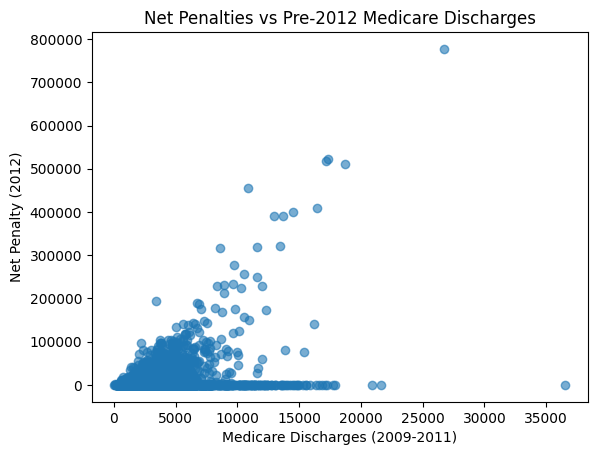

In [80]:
plt.figure()
plt.scatter(hcris_final["avg_mcare"], hcris_final["net_penalty"], alpha=0.6)
plt.xlabel("Medicare Discharges (2009-2011)")
plt.ylabel("Net Penalty (2012)")
plt.title("Net Penalties vs Pre-2012 Medicare Discharges")
plt.show()

## Question 8

In [83]:
hcris_final = hcris_final.dropna(subset=["avg_mcare", "avg_beds", "avg_medicaid", "net_penalty", "price_change"])
first_stage_py = smf.ols("net_penalty ~ avg_mcare", data=hcris_final).fit()
red_form_py   = smf.ols("price_change ~ avg_mcare", data=hcris_final).fit()
first_stage_py2 = smf.ols("net_penalty ~ avg_mcare + avg_beds", data=hcris_final).fit()
red_form_py2   = smf.ols("price_change ~ avg_mcare + avg_beds", data=hcris_final).fit()
first_stage_py3 = smf.ols("net_penalty ~ avg_mcare + avg_beds + avg_medicaid", data=hcris_final).fit()
red_form_py3   = smf.ols("price_change ~ avg_mcare + avg_beds + avg_medicaid", data=hcris_final).fit()

table = pd.DataFrame({
    "First Stage 1": {
        "Intercept": coef_se(first_stage_py, "Intercept"),
        "Pre-Penalty Medicare Discharges": coef_se(first_stage_py, "avg_mcare"),
        "Average Beds": "",
        "Average Medicaid Share": "",
        "N": int(first_stage_py.nobs),
        "R-squared": round(first_stage_py.rsquared, 3)
    },
    "First Stage 2": {
        "Intercept": coef_se(first_stage_py2, "Intercept"),
        "Pre-Penalty Medicare Discharges": coef_se(first_stage_py2, "avg_mcare"),
        "Average Beds": coef_se(first_stage_py2, "avg_beds"),
        "Average Medicaid Share": "",
        "N": int(first_stage_py2.nobs),
        "R-squared": round(first_stage_py2.rsquared, 3)
    },
    "First Stage 3": {
        "Intercept": coef_se(first_stage_py3, "Intercept"),
        "Pre-Penalty Medicare Discharges": coef_se(first_stage_py3, "avg_mcare"),
        "Average Beds": coef_se(first_stage_py3, "avg_beds"),
        "Average Medicaid Share": coef_se(first_stage_py3, "avg_medicaid"),
        "N": int(first_stage_py3.nobs),
        "R-squared": round(first_stage_py3.rsquared, 3)
    }
})

table

,First Stage 1,First Stage 2,First Stage 3
Intercept,-4453.917 (1215.671),-4448.497 (1216.394),-3775.703 (1226.243)
Pre-Penalty Medicare Discharges,4.732 (0.253),4.736 (0.254),5.270 (0.290)
Average Beds,,-0.081 (0.514),-0.028 (0.513)
Average Medicaid Share,,,-1.604 (0.426)
N,2462,2462,2462
R-squared,0.125,0.125,0.13


In [84]:
def coef_se(model, var):
    return f"{model.params[var]:.3f}({model.bse[var]:.3f})"
table2 = pd.DataFrame({
    "Reduced Stage 1": {       
        "Intercept": coef_se(red_form_py, "Intercept"),
        "Pre-Penalty Medicare Discharges": coef_se(red_form_py, "avg_mcare"),
        "Average Beds": "",
        "Average Medicaid Share": "",
        "N": int(red_form_py.nobs),
        "R-squared": round(red_form_py.rsquared, 3)
    },
    "Reduced Stage 2": {        
        "Intercept": coef_se(red_form_py2, "Intercept"),
        "Pre-Penalty Medicare Discharges": coef_se(red_form_py2, "avg_mcare"),
        "Average Beds": coef_se(red_form_py2, "avg_beds"),
        "Average Medicaid Share": "",
        "N": int(red_form_py2.nobs),
        "R-squared": round(red_form_py2.rsquared, 3)
    },
    "Reduced Stage 3": {
         "Intercept": coef_se(red_form_py3, "Intercept"),
        "Pre-Penalty Medicare Discharges": coef_se(red_form_py3, "avg_mcare"),
        "Average Beds": coef_se(red_form_py3, "avg_beds"),
        "Average Medicaid Share": coef_se(red_form_py3, "avg_medicaid"),
        "N": int(red_form_py3.nobs),
        "R-squared": round(red_form_py3.rsquared, 3)
    }
})

table2

,Reduced Stage 1,Reduced Stage 2,Reduced Stage 3
Intercept,237.577(110.901),232.337(110.904),157.224(111.641)
Pre-Penalty Medicare Discharges,0.024(0.023),0.020(0.023),-0.040(0.026)
Average Beds,,0.079(0.047),0.073(0.047)
Average Medicaid Share,,,0.179(0.039)
N,2462,2462,2462
R-squared,0.0,0.002,0.01


## Question 9

In [85]:
# IV/2SLS (Python)
hcris_final = hcris_final.dropna(subset=["net_penalty"])

if not HAVE_LINEARMODELS:
    raise ImportError("Install linearmodels to run IV2SLS: pip install linearmodels")

iv1 = IV2SLS.from_formula(
    "price_change ~ 1 + [net_penalty ~ avg_mcare]",
    data=hcris_final
).fit(cov_type="robust")

iv2 = IV2SLS.from_formula(
    "price_change ~ 1 + avg_beds + [net_penalty ~ avg_mcare]",
    data=hcris_final
).fit(cov_type="robust")

iv3 = IV2SLS.from_formula(
    "price_change ~ 1 + avg_beds + avg_medicaid + [net_penalty ~ avg_mcare]",
    data=hcris_final
).fit(cov_type="robust")

In [88]:
def coef_se_iv(model, var):
    return f"{model.params[var]:.3f} ({model.std_errors[var]:.3f})"

table_iv = pd.DataFrame({
    "IV1": {
        "Intercept": coef_se_iv(iv1, "Intercept"),
        "Net Penalty": coef_se_iv(iv1, "net_penalty"),
        "Average Beds": "",
        "Average Medicaid Share": "",
        "N": int(iv1.nobs),
    },
    "IV2": {
        "Intercept": coef_se_iv(iv2, "Intercept"),
        "Net Penalty": coef_se_iv(iv2, "net_penalty"),
        "Average Beds": coef_se_iv(iv2, "avg_beds"),
        "Average Medicaid Share": "",
        "N": int(iv2.nobs),
    },
    "IV3": {
        "Intercept": coef_se_iv(iv3, "Intercept"),
        "Net Penalty": coef_se_iv(iv3, "net_penalty"),
        "Average Beds": coef_se_iv(iv3, "avg_beds"),
        "Average Medicaid Share": coef_se_iv(iv3, "avg_medicaid"),
        "N": int(iv3.nobs),
    }
})

table_iv 

,IV1,IV2,IV3
Intercept,260.203 (97.367),251.108 (97.308),128.882 (113.591)
Net Penalty,0.005 (0.005),0.004 (0.005),-0.008 (0.006)
Average Beds,,0.079 (0.017),0.073 (0.011)
Average Medicaid Share,,,0.167 (0.078)
N,2462,2462,2462


## Question 10

The local ATE implies that these treatment effects greater are on hospitals with high Medicare Discharges (ie a high Medicare population). The effect of net penalties on prices should be higher in this population compared to hospitals with lower Medicare populations because this penalty has a large impact on their net profits.